# **Case Study 1: Intensive Care Beds Forecasting. Comparisons amongs LSTM, GRU, BiLSTM, Vanilla Transformers and then we include adjustments by LLMs**

# **All Installations**

In [47]:
%pip install transformers datasets peft accelerate evaluate torch --quiet
%pip install python-dotenv

# **All Imports**

In [48]:
import os
import gc
import re
import random
import timeit
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import warnings
from pathlib import Path
import statsmodels.api as sm
from tqdm.notebook import tqdm
from sklearn.metrics import mean_absolute_percentage_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning Imports
from tensorflow.keras import Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, LSTM, Bidirectional, Conv1D, GlobalAveragePooling1D, Dropout, MultiHeadAttention
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# LLMs Imports
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# **Globals**

In [49]:
from IPython.core.error import TryNext
neural_model = "LSTM"         # LSTM, GRU, BiLSTM

# Dataset
dataset_url = "https://raw.githubusercontent.com/pcm-dpc/COVID-19/master/dati-regioni/dpc-covid19-ita-regioni.csv"
selected_region = "Lazio"

start_intense_period = '2020-02-24'
end_intense_period   = '2020-06-17'

new_column_names_dict = {
    'data': 'date',
    'stato': 'state',
    'codice_regione': 'region code',
    'denominazione_regione': 'region name',
    'lat': 'latitude',
    'long': 'longitude',
    'ricoverati_con_sintomi': 'hospitalized_with_symptoms',
    'terapia_intensiva': 'intensive care',
    'totale_ospedalizzati': 'total hospitalized',
    'isolamento_domiciliare': 'home isolation',
    'totale_positivi': 'total positives',
    'variazione_totale_positivi': 'total positive change',
    'nuovi_positivi': 'new positives',
    'dimessi_guariti': 'discharged healed',
    'deceduti': 'deceased',
    'totale_casi': 'total cases',
    'tamponi': 'tampons',
    'casi_testati': 'total tests',
    'note_it': 'notes in italian',
    'note_en': 'notes in english'
}

# LLMs
llm_adjustment = True                                           # True means adjust predictions by LLM
llm_model_name = "meta-llama/Llama-3.2-1B-Instruct"             # ok, but not high, it's improving r2_score a little bit performance with penalty 1.3
#llm_model_name = "meta-llama/Llama-3.2-3B-Instruct"            # not ok, it's not generating any output, we need to work on hyperparameters
#llm_model_name = "meta-llama/Meta-Llama-3.1-8B-Instruct"       # not ok, less r2_score generated
#llm_model_name = "meta-llama/Meta-Llama-3.3-8B-Instruct"       # not working, maybe token
#llm_model_name = "Qwen/Qwen2.5-3B-Instruct"                    # not ok, a lot less r2_score generated
#llm_model_name = "Qwen/Qwen2.5-7B-Instruct"
#llm_model_name = "Qwen/Qwen2.5-14B-Instruct"
#llm_model_name = "Qwen/Qwen2.5-32B-Instruct"
#llm_model_name = "Qwen/Qwen2.5-72B-Instruct"
#llm_model_name = "mistralai/Mistral-7B-Instruct"

n_trials = 100
improvement_delta = 0.07
max_examples = 40
max_test_values = 40
max_tokens = 2048

# **All Code, Models and Pictures dowloads**

In [50]:
!cp -rp "./env" ./.env 2>/dev/null
load_dotenv()

True

# **Initializations**

In [51]:
warnings.filterwarnings('ignore')

# **Hyper-parameters**

In [52]:
epochs = 500
batch_size = 256
neural_cells = 600
num_attention_heads = 4

# **General Functions Definition**

In [53]:
def rmse(y, yhat):
    return root_mean_squared_error(y, yhat)
    #return np.sqrt(np.mean((y - yhat)**2))

def mae(y, yhat):
    return np.mean(np.abs(y - yhat))

def mape(y, yhat):
    # mean_absolute_percentage_error from sklearn returns a fraction, multiply by 100 for percentage
    return mean_absolute_percentage_error(y, yhat)

def r2score(y_true, y_pred):
    return r2_score(y_true, y_pred)

def metrics_compute(metric_name, model_name, model = None, scaler = None, X_dataset = None, dataset_y = None, X_train = None, train_y = None, X_test = None, test_y = None, y_hat = None, y_true = None):

  if metric_name.lower() == "rmse":
    metric = rmse
  elif metric_name.lower() == "mae":
    metric = mae
  elif metric_name.lower() == "mape":
    metric = mape
  else:
    metric = r2_score

  if X_dataset is not None:
    y_hat_data, y_true_data = denormalize_real_and_predicted_output(X_dataset, dataset_y, model, scaler)
    data_metric = metric(y_true_data, y_hat_data)
    print(f"{model_name} Data-set {metric_name}:", round(data_metric, 3))
  else:
    y_hat_data, y_true_data = y_true, y_hat
    data_metric = metric(y_true_data, y_hat_data)
    print(f"{model_name} Data-set {metric_name}:", round(data_metric, 3))

  if X_train is not None:
    y_hat_train, y_true_train = denormalize_real_and_predicted_output(X_train, train_y, model, scaler)
    train_metric = metric(y_true_train, y_hat_train)
    print(f"{model_name} Train-set {metric_name}:", round(train_metric, 3))
  else:
    y_hat_train, y_true_train, train_metric = None, None, None

  if X_test is not None:
    y_hat_test, y_true_test = denormalize_real_and_predicted_output(X_test, test_y, model, scaler)
    test_metric = metric(y_true_test, y_hat_test)
    print(f"{model_name} Test-set {metric_name}:", round(test_metric, 3))
  else:
    y_hat_test, y_true_test, test_metric = None, None, None

  return data_metric, train_metric, test_metric, y_hat_data, y_true_data, y_hat_train, y_true_train, y_hat_test, y_true_test

def adjusted_metrics_compute(metric_name, model_name, y_hat_test, y_true_test):

  if metric_name.lower() == "rmse":
    metric = rmse
  elif metric_name.lower() == "mae":
    metric = mae
  elif metric_name.lower() == "mape":
    metric = mape
  else:
    metric = r2_score

  test_metric = metric(y_true_test, y_hat_test)
  print(f"{model_name} Test-set {metric_name}:", round(test_metric, 3))

  return test_metric

def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
  '''
  Converts a time series into supervised learning
  '''

  n_vars = 1 if type(data) is list else data.shape[1]
  df = pd.DataFrame(data)
  cols, names = list(), list()
  for i in range(n_in, 0, -1):
    cols.append(df.shift(i))
    names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
  for i in range(0, n_out):
    cols.append(df.shift(-i))
    if i == 0:
      names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
    else:
      names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
  agg = pd.concat(cols, axis=1)
  agg.columns = names
  if dropnan:
    agg.dropna(inplace=True)
  return agg

def plot_curves(title, neural_model, set_type, denorm_y_pred, denorm_y_test, rmse, mae, mape, r_score):
  pred_df = pd.DataFrame({'Real Y' : denorm_y_test, 'Predicted Y' : denorm_y_pred})

  pred_title = title + "RMSE: "+str(np.round(rmse,3))+' - MAE: '+str(np.round(mae,3))+' - RSCORE: '+str(np.round(r_score,3)) + ' - MAPE: '+str(np.round(mape,3))

  plt.figure()												# generate a new window
  plt.plot(denorm_y_pred, label='Predicted Y', color = 'red')
  plt.plot(denorm_y_test, label='Real Y', color = 'blue')
  plt.legend()
  plt.title(pred_title)
  plt.savefig(f"./{neural_model}_forecasting_model_{set_type}_set_predictions.png", dpi = 600)
  plt.close()

  fig = px.line(pd.DataFrame(pred_df), title=pred_title,
                  labels={
                      "index": "Set Data Point",
                      "value": "Real Y / Predicted Y",
                      "variable": "Real / Predicted"
                  })
  fig.write_html(f"./{neural_model}_forecasting_model_{set_type}_set_predictions.html")
  fig.show()

# **Data Download**

In [54]:
df = pd.read_csv(dataset_url)
df.head()

,data,stato,codice_regione,denominazione_regione,lat,long,ricoverati_con_sintomi,terapia_intensiva,totale_ospedalizzati,isolamento_domiciliare,...,note,ingressi_terapia_intensiva,note_test,note_casi,totale_positivi_test_molecolare,totale_positivi_test_antigenico_rapido,tamponi_test_molecolare,tamponi_test_antigenico_rapido,codice_nuts_1,codice_nuts_2
0,2020-02-24T18:00:00,ITA,13,Abruzzo,42.351222,13.398438,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-24T18:00:00,ITA,17,Basilicata,40.639471,15.805148,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-24T18:00:00,ITA,18,Calabria,38.905976,16.594402,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-24T18:00:00,ITA,15,Campania,40.839566,14.250850,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-24T18:00:00,ITA,8,Emilia-Romagna,44.494367,11.341721,10,2,12,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Exploratory Data Analysis**

## **Columns Renaming**

In [55]:
df_exp = df.copy()
df_exp.rename(columns = new_column_names_dict, inplace = True)
df_exp.head()
df_exp['date'] = pd.to_datetime(df_exp.date).apply(lambda x: x.date())
df_exp['date'] = pd.to_datetime(df_exp.date)

In [56]:
df_exp.head()

,date,state,region code,region name,latitude,longitude,hospitalized_with_symptoms,intensive care,total hospitalized,home isolation,...,note,ingressi_terapia_intensiva,note_test,note_casi,totale_positivi_test_molecolare,totale_positivi_test_antigenico_rapido,tamponi_test_molecolare,tamponi_test_antigenico_rapido,codice_nuts_1,codice_nuts_2
0,2020-02-24,ITA,13,Abruzzo,42.351222,13.398438,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-24,ITA,17,Basilicata,40.639471,15.805148,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-24,ITA,18,Calabria,38.905976,16.594402,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-24,ITA,15,Campania,40.839566,14.250850,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-24,ITA,8,Emilia-Romagna,44.494367,11.341721,10,2,12,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Total Cases Line Plot**

In [57]:
total_df_exp = df_exp.groupby(by=['date'])['total cases'].sum()

In [58]:
total_df_exp.head(10)

,total cases
date,
2020-02-24,229
2020-02-25,322
2020-02-26,400
2020-02-27,650
2020-02-28,888
2020-02-29,1128
2020-03-01,1694
2020-03-02,2036
2020-03-03,2502


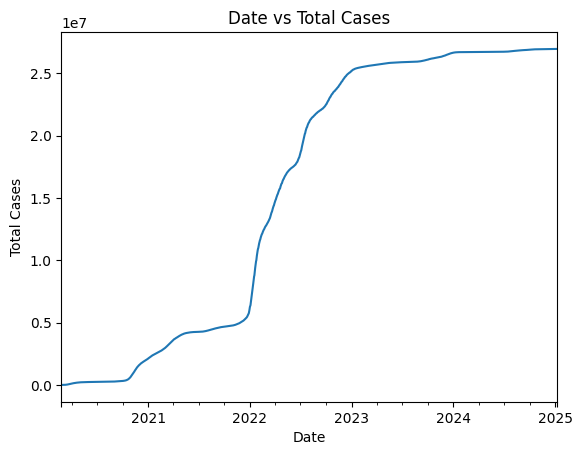

In [59]:
total_df_exp.plot()
plt.title("Date vs Total Cases")
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.show()

## **Logarithmic Total Cases Line Plot**

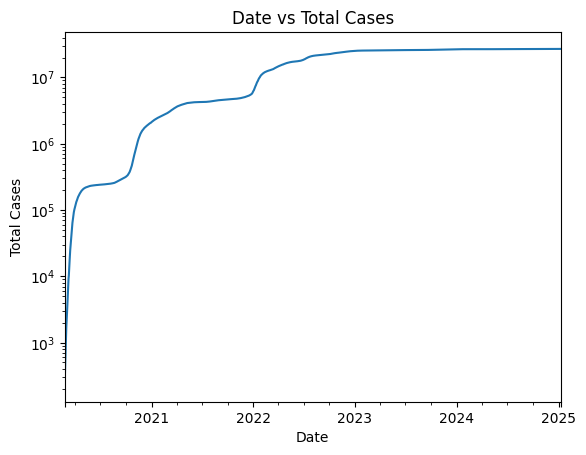

In [60]:
total_df_exp.plot(logy=True)
plt.title("Date vs Total Cases")
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.show()

## **Bar Plots**

In [61]:
total_s_exp = df_exp.groupby(by=['region name'])['new positives'].sum()

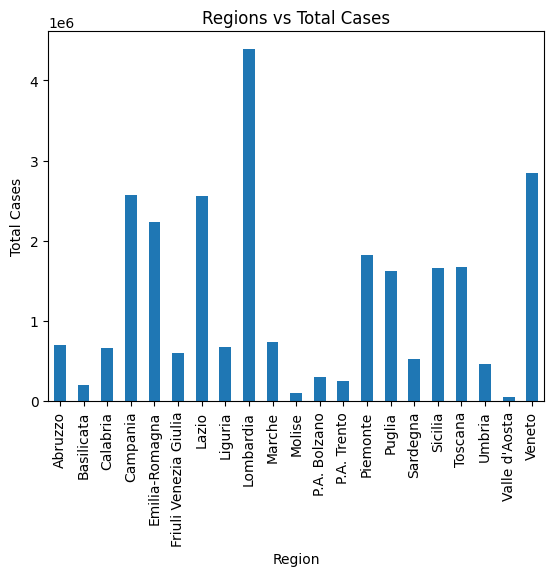

In [62]:
total_s_exp.plot.bar(stacked=False)
plt.title("Regions vs Total Cases")
plt.xlabel('Region')
plt.ylabel('Total Cases')
plt.show()

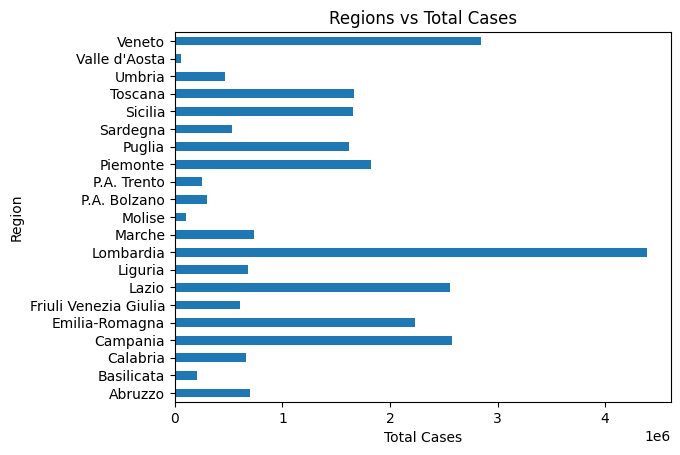

In [63]:
total_s_exp.plot.barh()
plt.title("Regions vs Total Cases")
plt.xlabel('Total Cases')
plt.ylabel('Region')
plt.show()

In [64]:
date_val = df_exp['date'][len(df_exp['date']) - 1]
mask = df_exp['date'] == date_val
f_df_exp = df_exp[mask]

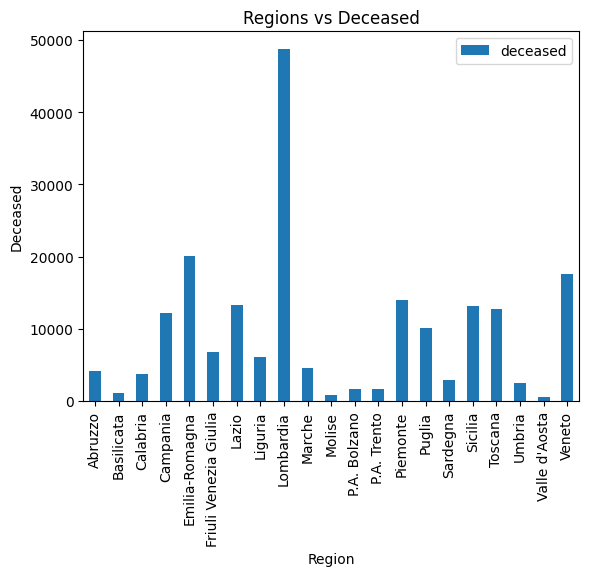

In [65]:
f_df_exp = f_df_exp[['region name', 'deceased']]
f_df_exp.plot.bar(x='region name', y='deceased')
plt.title("Regions vs Deceased")
plt.xlabel('Region')
plt.ylabel('Deceased')
plt.show()

## **Pie Chart**

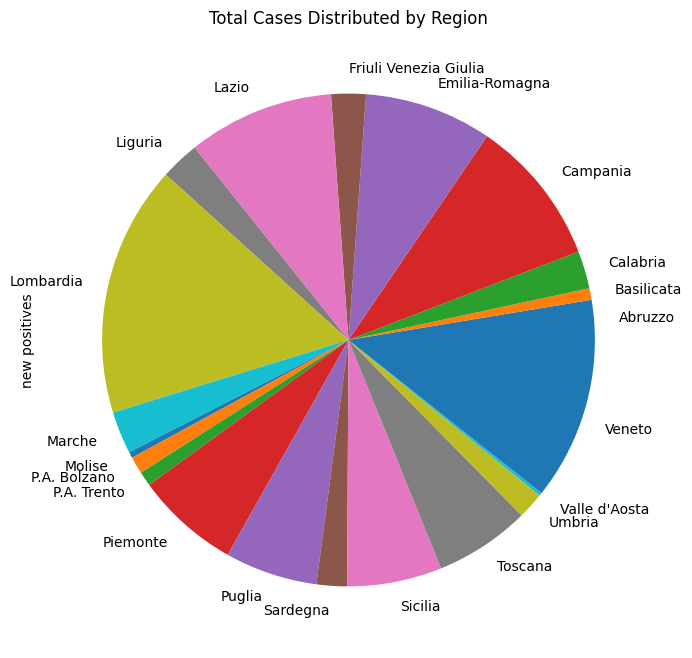

In [66]:
total_s_exp.plot.pie(figsize=(8,8))
plt.title("Total Cases Distributed by Region")
plt.show()

## **Line Plot**

In [67]:
total_c_exp = df_exp.groupby(by=['date'])['new positives'].sum()

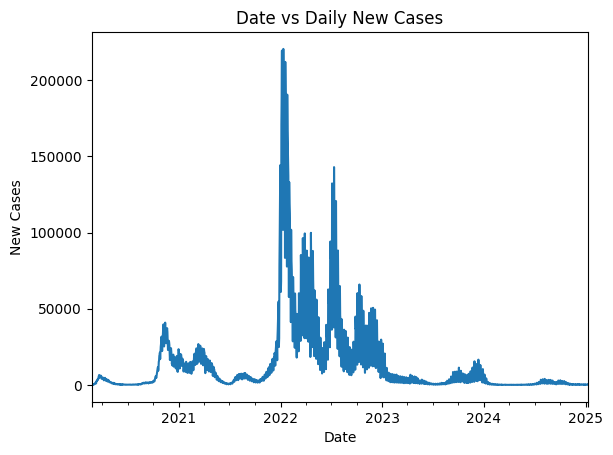

In [68]:
total_c_exp.plot.line()
plt.title("Date vs Daily New Cases")
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.show()

## **Selection of the Intense COVID Period**

In [69]:
intense_df_exp = df_exp.query('date >= @start_intense_period and date <= @end_intense_period')

In [70]:
intense_df_exp

,date,state,region code,region name,latitude,longitude,hospitalized_with_symptoms,intensive care,total hospitalized,home isolation,...,note,ingressi_terapia_intensiva,note_test,note_casi,totale_positivi_test_molecolare,totale_positivi_test_antigenico_rapido,tamponi_test_molecolare,tamponi_test_antigenico_rapido,codice_nuts_1,codice_nuts_2
0,2020-02-24,ITA,13,Abruzzo,42.351222,13.398438,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-02-24,ITA,17,Basilicata,40.639471,15.805148,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-02-24,ITA,18,Calabria,38.905976,16.594402,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-02-24,ITA,15,Campania,40.839566,14.250850,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-24,ITA,8,Emilia-Romagna,44.494367,11.341721,10,2,12,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2410,2020-06-17,ITA,19,Sicilia,38.115697,13.362357,25,3,28,777,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2411,2020-06-17,ITA,9,Toscana,43.769231,11.255889,33,14,47,397,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2412,2020-06-17,ITA,10,Umbria,43.106758,12.388247,7,2,9,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2413,2020-06-17,ITA,2,Valle d'Aosta,45.737503,7.320149,5,0,5,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Bar Plots with a more complex library: Seaborn**

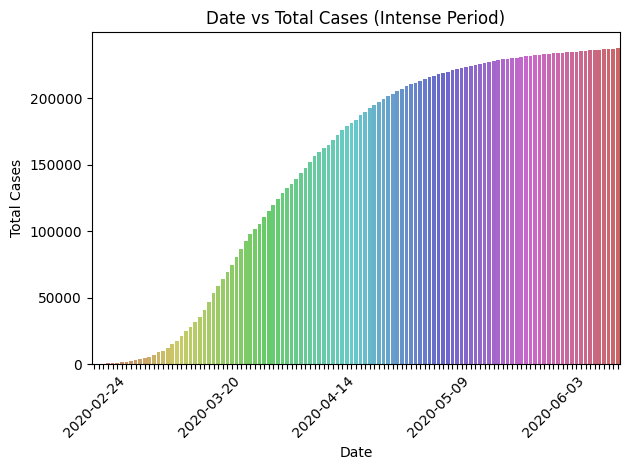

In [71]:
intense_cases_by_date = intense_df_exp.groupby(by=['date'])['total cases'].sum()
intense_cases_by_date_df = intense_cases_by_date.reset_index()
intense_cases_by_date_df.columns = ['Date', 'Total Cases']

plot_ = sns.barplot(
    x='Date',
    y='Total Cases',
    data=intense_cases_by_date_df,
    palette='hls'                 # Using a sequential color palette for gradient
)

# Apply the x-axis label visibility logic for better readability
for ind, label in enumerate(plot_.get_xticklabels()):
    if ind % 25 == 0:
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.title("Date vs Total Cases (Intense Period)")
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### **For the number of positives**

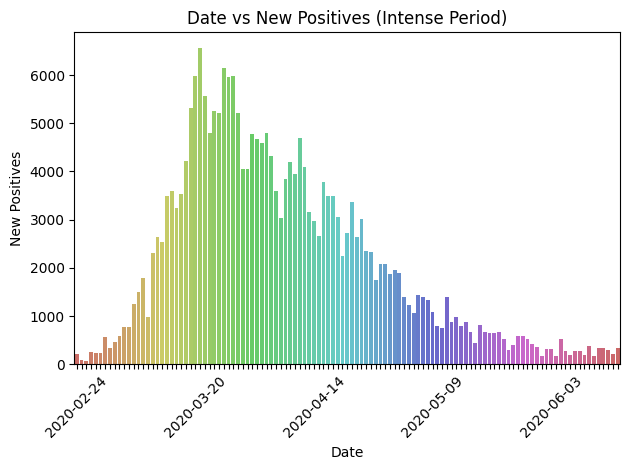

In [72]:
intense_new_positives_by_date = intense_df_exp.groupby(by=['date'])['new positives'].sum()
intense_new_positives_by_date_df = intense_new_positives_by_date.reset_index()
intense_new_positives_by_date_df.columns = ['Date', 'New Positives']

plot_ = sns.barplot(
    x='Date',
    y='New Positives',
    data=intense_new_positives_by_date_df,
    palette='hls' # Using a more colorful sequential color palette with pinkish end
)

# Apply the x-axis label visibility logic for better readability
for ind, label in enumerate(plot_.get_xticklabels()):
    if ind % 25 == 0:
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.title("Date vs New Positives (Intense Period)")
plt.xlabel('Date')
plt.ylabel('New Positives')
plt.xticks(rotation=45)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

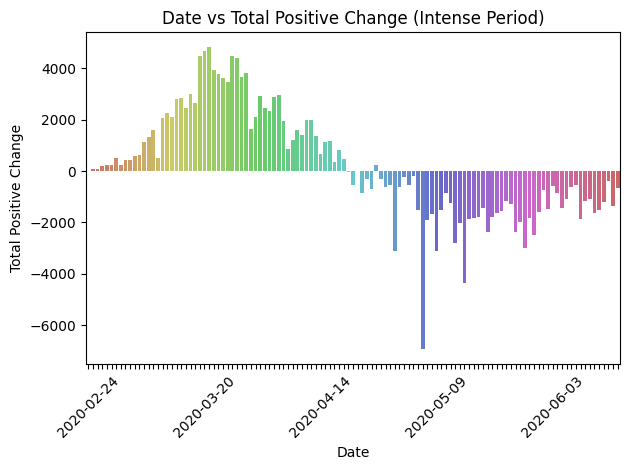

In [73]:
intense_total_positive_change_by_date = intense_df_exp.groupby(by=['date'])['total positive change'].sum()
intense_total_positive_change_by_date_df = intense_total_positive_change_by_date.reset_index()
intense_total_positive_change_by_date_df.columns = ['Date', 'Total Positive Change']

plot_ = sns.barplot(
    x='Date',
    y='Total Positive Change',
    data=intense_total_positive_change_by_date_df,
    palette='hls' # Using a more colorful sequential color palette with pinkish end
)

# Apply the x-axis label visibility logic for better readability
for ind, label in enumerate(plot_.get_xticklabels()):
    if ind % 25 == 0:
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.title("Date vs Total Positive Change (Intense Period)")
plt.xlabel('Date')
plt.ylabel('Total Positive Change')
plt.xticks(rotation=45)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# **Machine Learning Part**

# **Deep Learning Functions Definition**

In [74]:
def model_definition(X_train, summary = False, neural_cells = 50):
  rnn_input_shape = (X_train.shape[1], X_train.shape[2])
  model = Sequential()
  if neural_model == "GRU":
    model.add(GRU(neural_cells, input_shape = rnn_input_shape))
  elif neural_model == "LSTM":
    model.add(LSTM(neural_cells, input_shape = rnn_input_shape))
  elif neural_model == "BiLSTM":
    model.add(Bidirectional(LSTM(neural_cells), input_shape = rnn_input_shape))
  model.add(Dense(1, activation = "sigmoid"))
  model.compile(loss='mae', optimizer='adam')
  if summary is True:
    model.summary()

  return(model)

def auto_rnn(y_train, neural_model, k, epochs, verbose = 0, neural_cells = 50):
  #  Preprocessing for Deep Learning
  y_train_dl = np.reshape(y_train, (len(y_train), 1))
  y_train_dl.shape

  # Transformation from an unsupervised Time Series to a Supervised Dataset suitable for Deep Learning Supervised Models such as LSTM, GRU, Transformers, etc.
  supervised_full_dataset_df = series_to_supervised(y_train_dl, 1, 1)

  # Normalization
  scaler = MinMaxScaler(feature_range=(0, 1))
  supervised_scaled_full_dataset_df_values = scaler.fit_transform(supervised_full_dataset_df.values)

  # Train-Test Split
  X_dataset = supervised_scaled_full_dataset_df_values[:,:-1]
  y_dataset = supervised_scaled_full_dataset_df_values[:,-1]
  X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, test_size=0.20, shuffle = False)  # Shuffle = False since we do not have to unstructure temporal dependencies in time series
  X_dataset = X_dataset.reshape((X_dataset.shape[0], 1, X_dataset.shape[1]))
  X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
  X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

  if k == 0:
    model = model_definition(X_train, neural_cells)
  else:
    model = load_model(f"./{neural_model}_{epochs}_epochs_{neural_cells}_neural_cells_last.keras")

  history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=verbose, shuffle=False)

  model.save(f"./{neural_model}_{epochs}_epochs_{neural_cells}_neural_cells_last.keras")

  return model, scaler, X_train, y_train, X_test, y_test, X_dataset, y_dataset

def denormalize_real_and_predicted_output(X_test, y_test, forecasting_model, scaler):
  y_pred = forecasting_model.predict(X_test, verbose = 0)
  X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[2]))
  X_test_reshaped.shape

  denorm_X_test = np.concatenate((X_test_reshaped, y_pred), axis=1)
  denorm_X_test = scaler.inverse_transform(denorm_X_test)
  denorm_y_pred = denorm_X_test[:, denorm_X_test.shape[1]-1]

  y_test = y_test.reshape((len(y_test), 1))

  denorm_X_test = np.concatenate((X_test_reshaped, y_test), axis=1)
  denorm_X_test = scaler.inverse_transform(denorm_X_test)
  denorm_y_test = denorm_X_test[:, denorm_X_test.shape[1]-1]

  return(denorm_y_pred,denorm_y_test)

def denormalize_and_predicted_output(X_test, forecasting_model, scaler):
  X_test = np.reshape(X_test, (len(X_test), 1))
  y_pred = fit.predict(X_test, verbose = 0)
  denorm_y_pred = np.concatenate((X_test, y_pred), axis=1)
  denorm_y_pred = scaler.inverse_transform(denorm_y_pred)

  return denorm_y_pred[:, denorm_y_pred.shape[1]-1], denorm_y_pred[:, denorm_y_pred.shape[1]-1][-1]

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    #Attention
    x = MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res

def build_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = Input(shape=input_shape)
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = GlobalAveragePooling1D(data_format="channels_first")(x)
    for dim in mlp_units:
        x = Dense(dim, activation="relu")(x)
        x = Dropout(mlp_dropout)(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

def model_vt_definition(X_train, summary = False, num_attention_heads = 4):
  input_shape = (X_train.shape[1], X_train.shape[2])

  model_transf = build_model(
            input_shape,
            head_size=128,
            num_heads = num_attention_heads,
            ff_dim=6,
            num_transformer_blocks=6,
            mlp_units=[250],
            mlp_dropout=0.3,
            dropout=0.25,
        )

  model_transf.compile(
            loss="mae",
            optimizer=Adam(learning_rate=1e-4),
        )

  if summary is True:
    model_transf.summary()

  return model_transf

def auto_vt(y_train, k, epochs, verbose = 0, num_attention_heads = 4):
  #  Preprocessing for Deep Learning
  y_train_dl = np.reshape(y_train, (len(y_train), 1))
  y_train_dl.shape

  # Transformation from an unsupervised Time Series to a Supervised Dataset suitable for Deep Learning Supervised Models such as LSTM, GRU, Transformers, etc.
  supervised_full_dataset_df = series_to_supervised(y_train_dl, 1, 1)

  # Normalization
  scaler = MinMaxScaler(feature_range=(0, 1))
  supervised_scaled_full_dataset_df_values = scaler.fit_transform(supervised_full_dataset_df.values)

  # Train-Test Split
  X_dataset = supervised_scaled_full_dataset_df_values[:,:-1]
  y_dataset = supervised_scaled_full_dataset_df_values[:,-1]
  X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, test_size=0.20, shuffle = False)  # Shuffle = False since we do not have to unstructure temporal dependencies in time series
  X_dataset = X_dataset.reshape((X_dataset.shape[0], 1, X_dataset.shape[1]))
  X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
  X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

  if k == 0:
    model = model_vt_definition(X_train, num_attention_heads)
  else:
    model = load_model(f"./vanilla_transformer_{epochs}_epochs_{num_attention_heads}_num_attention_heads_last.keras")

  history_transf=model.fit(
            X_train,
            y_train,
            validation_data = (X_test, y_test),
            epochs = epochs,
            batch_size = batch_size,
            verbose = verbose,
            shuffle = False,
            )

  model.save(f"./vanilla_transformer_{epochs}_epochs_{num_attention_heads}_num_attention_heads_last.keras")

  return model, scaler, X_train, y_train, X_test, y_test, X_dataset, y_dataset

# **Data Preprocessing**

In [75]:
df_selected = df[df["denominazione_regione"] == selected_region]
df_selected = df_selected.sort_values("data")
y = df_selected["terapia_intensiva"].values.astype(float)

In [76]:
df_selected['data'] = pd.to_datetime(df_selected['data']).dt.floor('D')
df_selected['year_month'] = df_selected['data'].dt.to_period('M')

df_selected = (
    df_selected
    .drop_duplicates(subset=['year_month'], keep='first')
    [['data', 'terapia_intensiva']]
    .rename(columns={'data': 'Date', 'terapia_intensiva': 'y'})
    .reset_index(drop=True)
)

In [77]:
df_selected

,Date,y
0,2020-02-24,1
1,2020-03-01,0
2,2020-04-01,177
3,2020-05-01,105
4,2020-06-01,56
5,2020-07-01,12
6,2020-08-01,9
7,2020-09-01,8
8,2020-10-01,49
9,2020-11-01,185


# **LSTM, GRU, BiLSTM**

In [78]:
start_time = timeit.default_timer()
y_train = y
rnn_model, scaler, X_train, train_y, X_test, test_y, X_dataset, dataset_y = auto_rnn(y_train, neural_model, 0, epochs, verbose = 1, neural_cells = neural_cells)
print("Elapsed LSTM Time: ", timeit.default_timer() - start_time)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.3541 - val_loss: 0.4854
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3517 - val_loss: 0.4817
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3491 - val_loss: 0.4780
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.3466 - val_loss: 0.4741
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.3440 - val_loss: 0.4701
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.3413 - val_loss: 0.4660
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.3385 - val_loss: 0.4616
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.3355 - val_loss: 0.4570
Epoch 9/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.3324 - val_loss: 0.4522
Epoch 10/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3291 - val_loss: 0.4470
Epoch 11/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.3257 - val_loss: 0.4416
Epoch 12/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3222 - val_l

## **LSTM, GRU, BiLSTM Performance Evaluation**

In [79]:
for metric in ["RMSE", "MAE", "MAPE", "R2-SCORE"]:
  data_metric_rnn, train_metric_rnn, test_metric_rnn, y_hat_data_rnn, y_true_data_rnn, y_hat_train_rnn, y_true_train_rnn, y_hat_test_rnn, y_true_test_rnn = metrics_compute(metric, neural_model, rnn_model, scaler, X_dataset, dataset_y, X_train, train_y, X_test, test_y)
  if metric == "RMSE":
    data_rmse_rnn = data_metric_rnn
    train_rmse_rnn = train_metric_rnn
    test_rmse_rnn = test_metric_rnn
  elif metric == "MAE":
    data_mae_rnn = data_metric_rnn
    train_mae_rnn = train_metric_rnn
    test_mae_rnn = test_metric_rnn
  elif metric == "MAPE":
    data_mape_rnn = data_metric_rnn
    train_mape_rnn = train_metric_rnn
    test_mape_rnn = test_metric_rnn
  else:
    data_r2_score_rnn = data_metric_rnn
    train_r2_score_rnn = train_metric_rnn
    test_r2_score_rnn = test_metric_rnn

  print("\n")

LSTM Data-set RMSE: 13.075
LSTM Train-set RMSE: 12.532
LSTM Test-set RMSE: 15.052


LSTM Data-set MAE: 10.928
LSTM Train-set MAE: 9.925
LSTM Test-set MAE: 14.94


LSTM Data-set MAPE: 318093933759915.2
LSTM Train-set MAPE: 397617417199892.6
LSTM Test-set MAPE: 5.439


LSTM Data-set R2-SCORE: 0.981
LSTM Train-set R2-SCORE: 0.984
LSTM Test-set R2-SCORE: -27.813




## **Real and Predicted Curves Visualization for RNN**

## **Dataset**

In [80]:
plot_curves("Dataset - ", neural_model, "data", y_hat_data_rnn, y_true_data_rnn, data_rmse_rnn, data_mae_rnn, data_mape_rnn, data_r2_score_rnn)

## **Trainset**

In [81]:
plot_curves("Train-set - ", neural_model, "train", y_hat_train_rnn, y_true_train_rnn, train_rmse_rnn, train_mae_rnn, train_mape_rnn, train_r2_score_rnn)

## **Testset**

In [82]:
  plot_curves("Test-set - ", neural_model, "test", y_hat_test_rnn, y_true_test_rnn, test_rmse_rnn, test_mae_rnn, test_mape_rnn, test_r2_score_rnn)

# **Vanilla Transformer**

In [83]:
start_time = timeit.default_timer()
y_train = y
vt_model, scaler, X_train, train_y, X_test, test_y, X_dataset, dataset_y = auto_vt(y_train, 0, epochs, verbose = 1, num_attention_heads = num_attention_heads)
print("Elapsed LSTM Time: ", timeit.default_timer() - start_time)

Epoch 1/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - loss: 0.2056 - val_loss: 0.0054
Epoch 2/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1925 - val_loss: 0.0106
Epoch 3/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1804 - val_loss: 0.0222
Epoch 4/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1687 - val_loss: 0.0343
Epoch 5/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1616 - val_loss: 0.0450
Epoch 6/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1547 - val_loss: 0.0536
Epoch 7/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1511 - val_loss: 0.0594
Epoch 8/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1441 - val_loss: 0.0628
Epoch 9/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1370 - val_loss: 0.0639
Epoch 10/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1346 - val_loss: 0.0631
Epoch 11/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1279 - val_loss: 0.0608
Epoch 12/500
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1208 - val_los

## **Vanilla Transformer Predictions Performance Evaluation**

In [84]:
for metric in ["RMSE", "MAE", "MAPE", "R2-SCORE"]:
  data_metric_vt, train_metric_vt, test_metric_vt, y_hat_data_vt, y_true_data_vt, y_hat_train_vt, y_true_train_vt, y_hat_test_vt, y_true_test_vt = metrics_compute(metric, "Vanilla Transformer", vt_model, scaler, X_dataset, dataset_y, X_train, train_y, X_test, test_y)
  if metric == "RMSE":
    data_rmse_vt = data_metric_vt
    train_rmse_vt = train_metric_vt
    test_rmse_vt = test_metric_vt
  elif metric == "MAE":
    data_mae_vt = data_metric_vt
    train_mae_vt = train_metric_vt
    test_mae_vt = test_metric_vt
  elif metric == "MAPE":
    data_mape_vt = data_metric_vt
    train_mape_vt = train_metric_vt
    test_mape_vt = test_metric_vt
  else:
    data_r2_score_vt = data_metric_vt
    train_r2_score_vt = train_metric_vt
    test_r2_score_vt = test_metric_vt

  print("\n")

Vanilla Transformer Data-set RMSE: 4.025
Vanilla Transformer Train-set RMSE: 4.47
Vanilla Transformer Test-set RMSE: 1.025


Vanilla Transformer Data-set MAE: 2.415
Vanilla Transformer Train-set MAE: 2.811
Vanilla Transformer Test-set MAE: 0.831


Vanilla Transformer Data-set MAPE: 35672205535963.87
Vanilla Transformer Train-set MAPE: 44590256919954.75
Vanilla Transformer Test-set MAPE: 0.322


Vanilla Transformer Data-set R2-SCORE: 0.998
Vanilla Transformer Train-set R2-SCORE: 0.998
Vanilla Transformer Test-set R2-SCORE: 0.866




## **Real and Predicted Curves Visualization for Vanilla Transformer**

## **Dataset**

In [85]:
plot_curves("Dataset - ", "vt", "data", y_hat_data_vt, y_true_data_vt, data_rmse_vt, data_mae_vt, data_mape_vt, data_r2_score_vt)

## **Trainset**

In [86]:
plot_curves("Train-set - ", "vt", "train", y_hat_train_vt, y_true_train_vt, train_rmse_vt, train_mae_vt, train_mape_vt, train_r2_score_vt)

## **Testset**

In [87]:
plot_curves("Test-set - ", "vt", "test", y_hat_test_vt, y_true_test_vt, test_rmse_vt, test_mae_vt, test_mape_vt, test_r2_score_vt)

In [88]:
y_true_train_vt_df = pd.DataFrame(y_true_train_vt)
y_hat_train_vt_df = pd.DataFrame(y_hat_train_vt)
y_hat_test_vt_df = pd.DataFrame(y_hat_test_vt)
y_true_test_vt_df = pd.DataFrame(y_true_test_vt)
y_true_train_vt_df.to_csv("./y_true_train_vt.csv")
y_hat_train_vt_df.to_csv("./y_hat_train_vt.csv")
y_hat_test_vt_df.to_csv("./y_hat_test_vt.csv")
y_true_test_vt_df.to_csv("./y_true_test_vt.csv")

# **Adjustment by Open-Weight LLMs**

In [89]:
if llm_adjustment is True:
  start_time = timeit.default_timer()

  tokenizer = AutoTokenizer.from_pretrained(llm_model_name)
  tokenizer.pad_token = tokenizer.eos_token

  llm_model = AutoModelForCausalLM.from_pretrained(
      llm_model_name,
      torch_dtype=torch.float16,
      device_map="auto"
  )

  for k in range(n_trials):

    train_y = y_true_train_vt.tolist()
    train_pred = y_hat_train_vt.tolist()
    test_pred = y_hat_test_vt.tolist()

    examples = []


    for y_true, y_pred in list(zip(train_y[:max_examples], train_pred[:max_examples])):
        examples.append(
            f"Model prediction: {y_pred:.5f}\n"
            f"Correct real value: {y_true:.5f}\n"
        )

    system_instruction = (
        "You are an expert model in time series correction. "
        "You will be shown a model's predictions and the correct real values. "
        "Learn the type of error and how to correct it. "
        "Then you will receive only new predictions and must return "
        "the corrected versions, one per line, NUMBERS ONLY."
    )

    base_prompt = (
        f"{system_instruction}\n\n"
        "CORRECTION EXAMPLES:\n"
        f"{'\n'.join(examples)}\n"
    )

    test_values = "\n".join([f"{v:.5f}" for v in test_pred[:max_test_values]])

    test_prompt = (
        base_prompt +
        "NOW CORRECT THESE NEW PREDICTIONS\n"
        "Model predictions to correct:\n"
        f"{test_values}\n\n"
        "Corrected values:"
    )

    inputs = tokenizer(
        test_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(llm_model.device)

    if n_trials == 1:
      with torch.no_grad():
          output = llm_model.generate(
              **inputs,
              max_new_tokens=max_tokens,
              temperature=0.2,
              repetition_penalty=1.3,
              do_sample=False,
              pad_token_id=tokenizer.eos_token_id
          )
    else:
      with torch.no_grad():
          output = llm_model.generate(
              **inputs,
              max_new_tokens=max_tokens,
              temperature=random.uniform(0.0, 1.2),
              repetition_penalty=random.uniform(1.0, 1.6),
              do_sample=False,
              pad_token_id=tokenizer.eos_token_id
          )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)

    corrected_part = decoded.split("Corrected values:")[-1].strip()

    numbers = re.findall(r"-?\d+\.\d+|-?\d+", corrected_part)
    numbers = [float(n) for n in numbers]
    numbers = np.array(numbers)

    if len(numbers) < max_test_values:
      y_hat_test_vt_adjusted = numbers
      y_true_test_vt_for_adj = y_true_test_vt[0:len(numbers)]
    else:
      y_hat_test_vt_adjusted = numbers[0:max_test_values]
      y_true_test_vt_for_adj = y_true_test_vt[0:max_test_values]

    if numbers.size > 0:
      print(f"\nTrial {k}: ")
      for metric in ["RMSE", "MAE", "MAPE", "R2-SCORE"]:
        test_metric_vt = adjusted_metrics_compute(
            metric,
            "Vanilla Transformer",
            y_hat_test_vt_adjusted,
            y_true_test_vt_for_adj
        )

        if metric == "RMSE":
          test_rmse_vt_adjusted = test_metric_vt
        elif metric == "MAE":
          test_mae_vt_adjusted = test_metric_vt
        elif metric == "MAPE":
          test_mape_vt_adjusted = test_metric_vt
        else:
          test_r2_score_vt_adjusted = test_metric_vt
    else:
      print(f"\nTrial {k}: no values in output")

    del inputs
    del output

    torch.cuda.empty_cache()
    gc.collect()

    if test_r2_score_vt_adjusted > test_r2_score_vt + improvement_delta:
      break

  print("Elapsed LLM Time: ", timeit.default_timer() - start_time)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]


Trial 0: 
Vanilla Transformer Test-set RMSE: 1.527
Vanilla Transformer Test-set MAE: 1.23
Vanilla Transformer Test-set MAPE: 0.136
Vanilla Transformer Test-set R2-SCORE: 0.596

Trial 1: 
Vanilla Transformer Test-set RMSE: 1.527
Vanilla Transformer Test-set MAE: 1.23
Vanilla Transformer Test-set MAPE: 0.136
Vanilla Transformer Test-set R2-SCORE: 0.596

Trial 2: 
Vanilla Transformer Test-set RMSE: 1.527
Vanilla Transformer Test-set MAE: 1.23
Vanilla Transformer Test-set MAPE: 0.136
Vanilla Transformer Test-set R2-SCORE: 0.596

Trial 3: 
Vanilla Transformer Test-set RMSE: 18.667
Vanilla Transformer Test-set MAE: 18.277
Vanilla Transformer Test-set MAPE: 2.024
Vanilla Transformer Test-set R2-SCORE: -59.344

Trial 4: 
Vanilla Transformer Test-set RMSE: 30.111
Vanilla Transformer Test-set MAE: 30.111
Vanilla Transformer Test-set MAPE: 2.316
Vanilla Transformer Test-set R2-SCORE: nan

Trial 5: 
Vanilla Transformer Test-set RMSE: 53.629
Vanilla Transformer Test-set MAE: 40.071
Vanilla Transfo

## **Adjusted Test Set Predictions Performance Evaluation**

In [90]:
if llm_adjustment is True:
  plot_curves("Test-set - ", llm_model_name[0:7].replace('/','_'), "test", y_hat_test_vt_adjusted, y_true_test_vt_for_adj, test_rmse_vt_adjusted, test_mae_vt_adjusted, test_mape_vt_adjusted, test_r2_score_vt_adjusted)